In [116]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np

In [102]:
# Cargar el dataset de Fashion MNIST
data, metadata = tfds.load('fashion_mnist', as_supervised=True, with_info=True)

In [103]:
# Dividir el dataset en entrenamiento y prueba
train_dataset, test_dataset = data['train'], data['test']

In [104]:
# Obtener las clases del dataset
classes = metadata.features['label'].names

In [105]:
print(classes)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [106]:
# Normalizar los datos (Pasar de 0-255 a 0-1)
def normalize(image: tf.Tensor, label: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor]:
    image = tf.cast(image, tf.float32)
    image /= 255
    return image, label

train_dataset = train_dataset.map(normalize)
test_dataset = test_dataset.map(normalize)

# Agregar a cache (usar memoria para acelerar el entrenamiento)
train_dataset = train_dataset.cache()
test_dataset = test_dataset.cache()

W0000 00:00:1785879350.711046  206014 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
W0000 00:00:1785879350.711099  206014 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


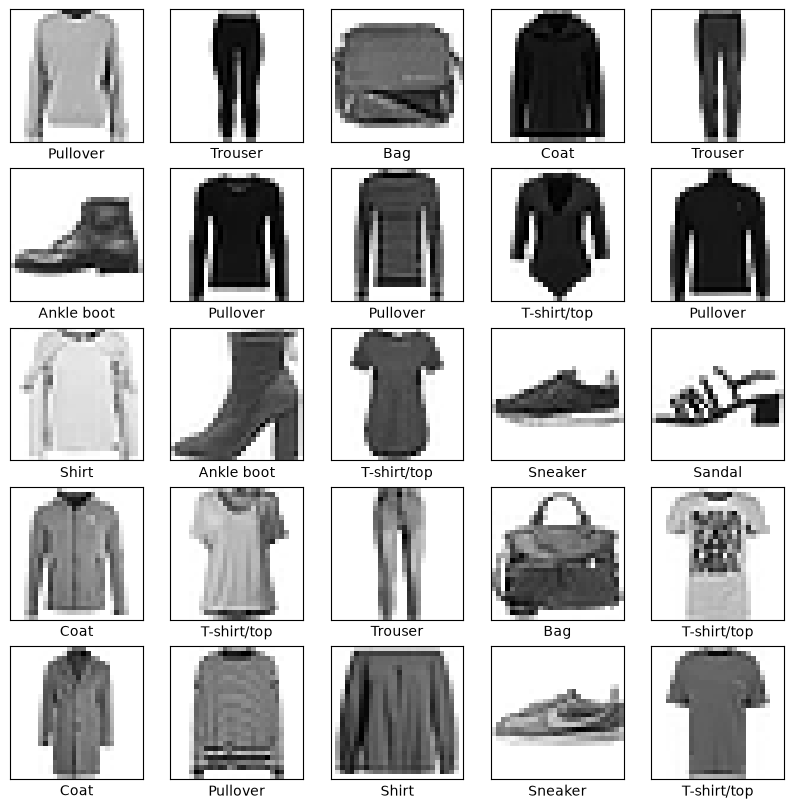

In [107]:
# Mostrar algunas imágenes con sus etiquetas del dataset
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(train_dataset.take(25)):
    image = image.numpy().reshape((28, 28))
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(image, cmap=plt.cm.binary)
    plt.xlabel(classes[label])
plt.show()

In [ ]:
# Crear el modelo

model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    tf.keras.layers.Flatten(),  # Aplanar la imagen de 28x28 a un vector de 784 elementos
    # Capas ocultas densas con 50 neuronas y función de activación ReLU
    tf.keras.layers.Dense(50, activation='relu'),
    tf.keras.layers.Dense(50, activation='relu'),
    # Capa de salida con 10 neuronas y función de activación softmax
    # La función softmax se usa como función de activación en la capa de salida en las redes de clasificación multiclase.
    # Asegurando que la suma de todas las salidas sea igual a 1.
    # Esto permite interpretar las salidas como probabilidades de pertenencia a cada clase.
    tf.keras.layers.Dense(10, activation='softmax')
])

In [109]:
# Compilar el modelo

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [110]:
train_dataset_size = metadata.splits['train'].num_examples
test_dataset_size = metadata.splits['test'].num_examples

In [111]:
LOTE = 32

# Preparar los datasets para el entrenamiento (idempotente: siempre parte del dataset base)
train_dataset = data['train'].map(normalize).cache().repeat().shuffle(train_dataset_size).batch(LOTE)
test_dataset = data['test'].map(normalize).cache().batch(LOTE)

In [ ]:
# Entrear modelo
import math

history = model.fit(train_dataset, epochs=10, steps_per_epoch=math.ceil(train_dataset_size/LOTE))

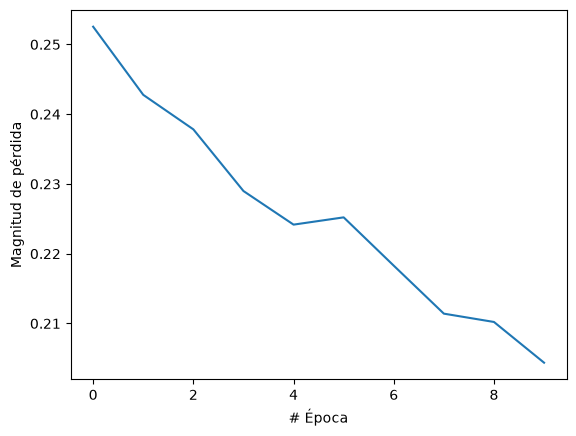

In [115]:
# Graficar resultados de la función de pérdida en cada epoca
plt.xlabel('# Época')
plt.ylabel('Magnitud de pérdida')
plt.plot(history.history['loss'])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


W0000 00:00:1785880495.614264  224665 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
W0000 00:00:1785880495.614308  224665 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


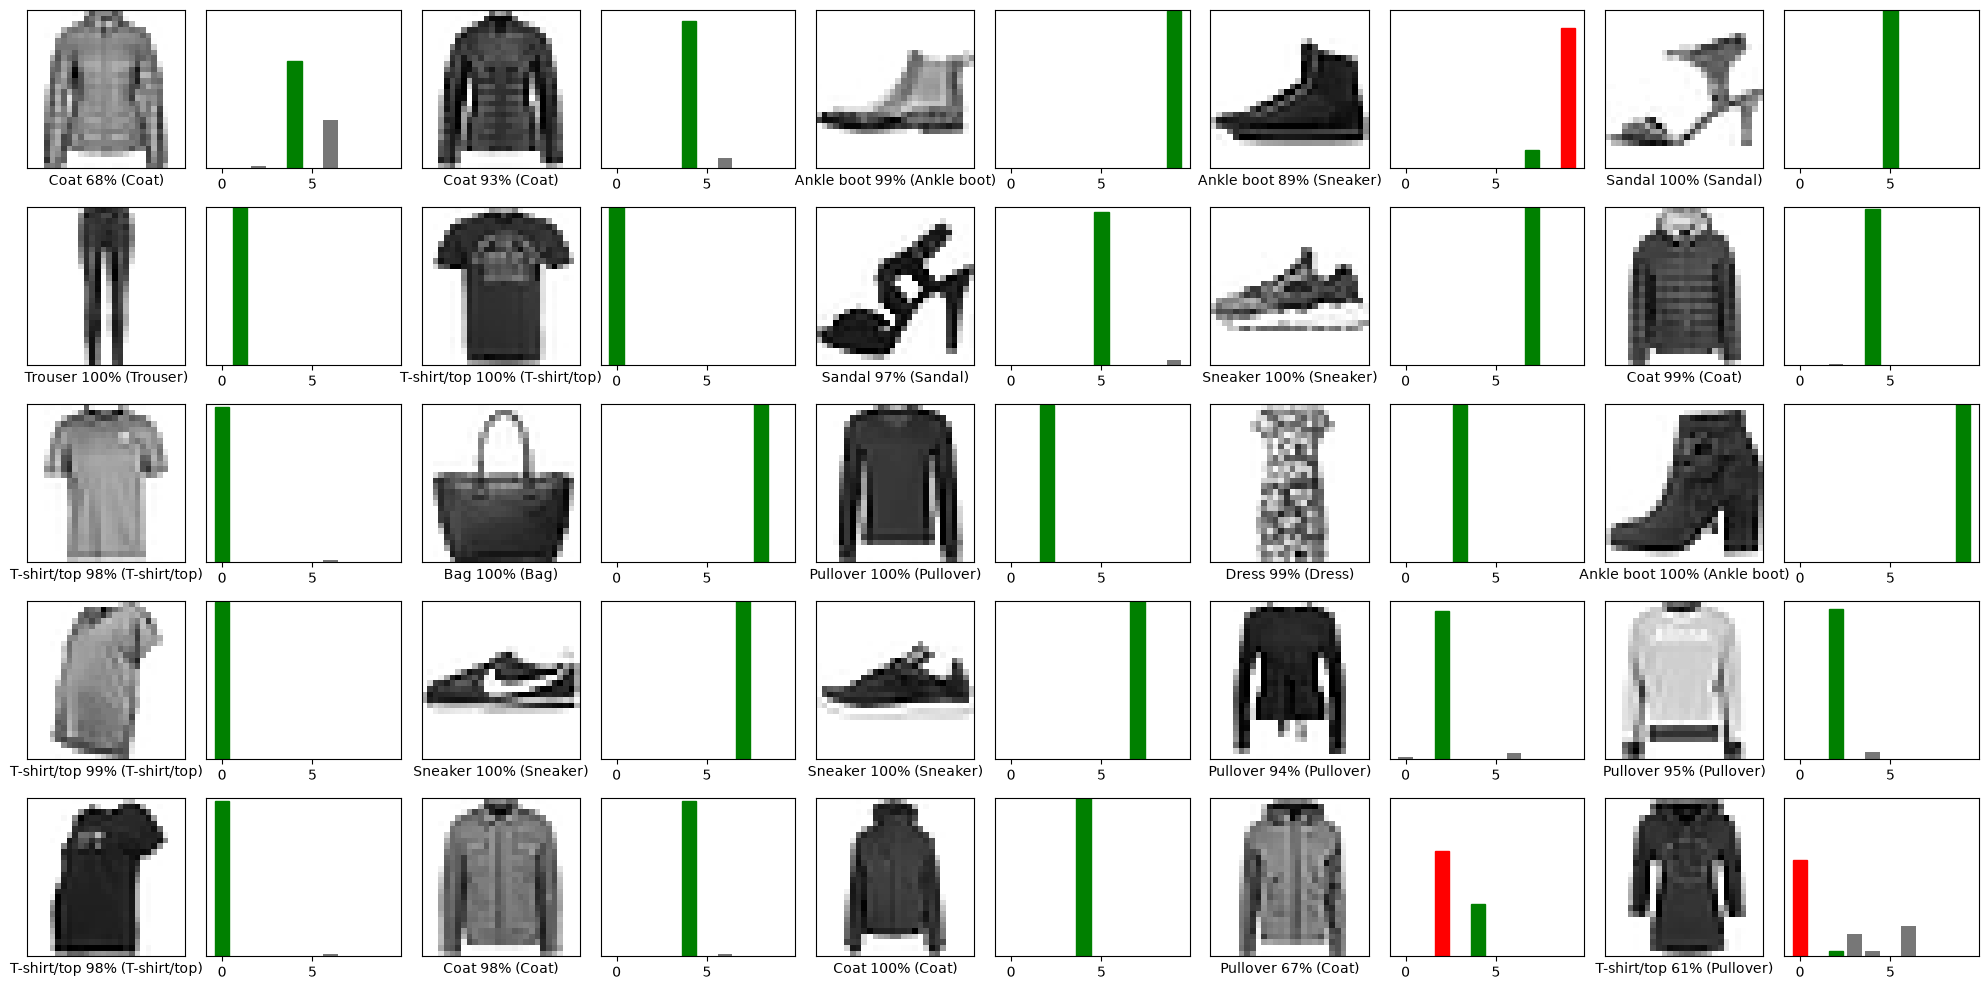

In [127]:
# Predecir 25 imagenes del conjunto de prueba, si predice correctamente, usar una barra verde, si no, una barra roja
for test_images, test_labels in test_dataset.take(1):
    test_images = test_images.numpy()
    test_labels = test_labels.numpy()
    predictions = model.predict(test_images)

def graph_image(i, predictions_array, true_label, img):
    predictions_array, true_label, img = predictions_array[i], true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img[..., 0], cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'green'
    else:
        color = 'red'

    plt.xlabel("{} {:2.0f}% ({})".format(classes[predicted_label],
                                         100 * np.max(predictions_array),
                                         classes[true_label],
                                         color=color))


def graph_value_array(i, predictions_array, true_label):
    predictions_array, true_label = predictions_array[i], true_label[i]
    plt.grid(False)
    plt.xticks()
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)

    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('green')


rows = 5
cols = 5
num_images = rows * cols
plt.figure(figsize=(2 * 2 * cols, 2 * rows))
for i in range(num_images):
    plt.subplot(rows, 2 * cols, 2 * i + 1)
    graph_image(i, predictions, test_labels, test_images)
    plt.subplot(rows, 2 * cols, 2 * i + 2)
    graph_value_array(i, predictions, test_labels)
    plt.tight_layout()
plt.show()

In [ ]:

# Predecir una imagen del dataset de prueba
img = test_images[3]
img = np.array([img]) # Agregar una dimension para que sea un batch de 1 imagen
predictions_single = model.predict(img)
print(classes[np.argmax(predictions_single[0])]) # Imprimir la categoria predicha

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Ankle boot
